# 3.4 Diffusion on a sphere

## Environment configuration

CPU: 13th Gen Intel(R) Core(TM) i7-13700K 64GB

python==3.13.9 torch==2.9.1

In [1]:
import torch
from cibsde import nn, utils
import matplotlib.pyplot as plt
device = 'cpu'
seed = 666
torch.manual_seed(seed)

## Parameter settings

In [2]:
# model parameters
num_sphere = 1
d = 2
t = torch.tensor([0.25,0.5,0.75,1],device=device)
D = torch.tensor([0.5],device=device)
N = [25,50,75,100]
# training parameters
batch = 512
epoch = 10**4
lr = 1e-3
train_params = {
    'epoch': epoch,
    'batch': batch,
    'lr': lr
}

## Model initialization

In [3]:
def data_gen(batch):
    u1 = torch.rand([batch],device=device)
    u2 = torch.rand([batch],device=device)
    sign = torch.sign(torch.randn([batch],device=device))
    phi = 2 * torch.pi * u1
    theta = torch.arccos(1 - u2)
    x = torch.sin(theta) * torch.cos(phi)
    y = torch.sin(theta) * torch.sin(phi)
    z = torch.cos(theta)*sign
    return torch.stack([x,y,z],dim=1).to(device)

def pc(i,x):
    x_polar = utils.polar_corr(x)
    return (x_polar[:,:1]>torch.pi/4)*(x_polar[:,:1]<torch.pi*3/4)/torch.sin(x_polar[:,:1])

def refb(x):
    return x, x, torch.zeros(batch,device=device).bool()

def hitb(x):
    return torch.zeros(batch,device=device).bool()

def h(t,x):
    return torch.zeros([x.shape[0],1],device=device)

def f(t,xt,p):
    return torch.zeros([batch,1],device=device)

models = [nn.SphereIBSDE(
    dx = num_sphere,
    t = t[i],
    f = f,
    D = D,
    h = h,
    pc = pc,
    data_gen = data_gen,
    N = N[i],
    refb = refb,
    hitb = hitb
).to(device) for i in range(4)]

## Model training

In [4]:
loss_values = [nn.train(
    model,
    train_params
) for model in models]

100%|██████████| 10000/10000 [05:51<00:00, 28.43it/s, loss=5.710621e-02]



Training has been completed.


100%|██████████| 10000/10000 [11:44<00:00, 14.19it/s, loss=5.990297e-02]



Training has been completed.


100%|██████████| 10000/10000 [16:57<00:00,  9.83it/s, loss=5.890641e-02]



Training has been completed.


100%|██████████| 10000/10000 [22:28<00:00,  7.42it/s, loss=4.582069e-02]


Training has been completed.


## PINN

In [5]:
class PINN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.p = utils.FNN(4,1)
    
    def forward(self, batch):
        u1 = torch.rand(batch,device=device)
        u2 = torch.rand(batch,device=device)

        phi = 2 * torch.pi * u1
        theta = torch.arccos(2 * u2 - 1)

        phi.requires_grad = True
        theta.requires_grad = True

        x = torch.sin(theta) * torch.cos(phi)
        y = torch.sin(theta) * torch.sin(phi)
        z = torch.cos(theta)
        ps = torch.stack([x, y, z], dim=1)
        t = torch.rand([batch,1],device=device,requires_grad=True)

        u1 = torch.rand(batch,device=device)
        u2 = torch.rand(batch,device=device)

        phiT = 2 * torch.pi * u1
        thetaT = torch.arccos(2 * u2 - 1)

        xT = torch.sin(thetaT) * torch.cos(phiT)
        yT = torch.sin(thetaT) * torch.sin(phiT)
        zT = torch.cos(thetaT)
        psT = torch.stack([xT, yT, zT], dim=1)
        T = torch.ones([batch,1],device=device)
        sintheta = torch.sin(theta)
        u = self.p(torch.cat([t,ps],dim=1))
        
        grad_theta = torch.autograd.grad(u,theta,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
        grad_phi = torch.autograd.grad(u,phi,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
        singrad_theta = torch.autograd.grad(grad_theta*sintheta,theta,torch.ones_like(grad_theta),retain_graph=True,create_graph=True)[0].unsqueeze(1)
        grad2_phi = torch.autograd.grad(grad_phi,phi,torch.ones_like(grad_phi),retain_graph=True,create_graph=True)[0].unsqueeze(1)
        ut = torch.autograd.grad(u,t,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
        uT = self.p(torch.cat([T,psT],dim=1))
        return torch.cat([ut,uT]), torch.cat([-D*(singrad_theta/sintheta.unsqueeze(1)+grad2_phi/sintheta.unsqueeze(1)**2),pc(100,psT)])

## PINN initialization

In [6]:
pinn = PINN().to(device)

## PINN training

In [7]:
loss_value_pinn = nn.train(
    pinn,
    train_params
)

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [01:31<00:00, 109.71it/s, loss=4.253037e-02]


Training has been completed.


## Loading reference solution

In [8]:
y_rel = torch.load('./datasets/example4.pth')

## Plot figures

In [9]:
shape = [200,200]
theta = torch.linspace(0,torch.pi,shape[0])
phi = torch.linspace(0,torch.pi*2,shape[1])
theta,phi = torch.meshgrid(theta,phi,indexing='ij')
x_polar = torch.stack([theta.reshape(shape[0]*shape[1]),phi.reshape(shape[0]*shape[1])],dim=1)
x = utils.euclid_corr(x_polar).reshape([200,200,3])
tt = torch.ones([4,200*200,1]) * (1-t[:,None,None])
y_pinn = [pinn.p(torch.cat([tt[i],x.reshape(200*200,3)],dim=1).to(device)).cpu().detach().reshape(200,200) for i in range(4)]
y_pre = [model.p(x.to(device).reshape(200*200,3)).cpu().detach().reshape(200,200) for model in models]

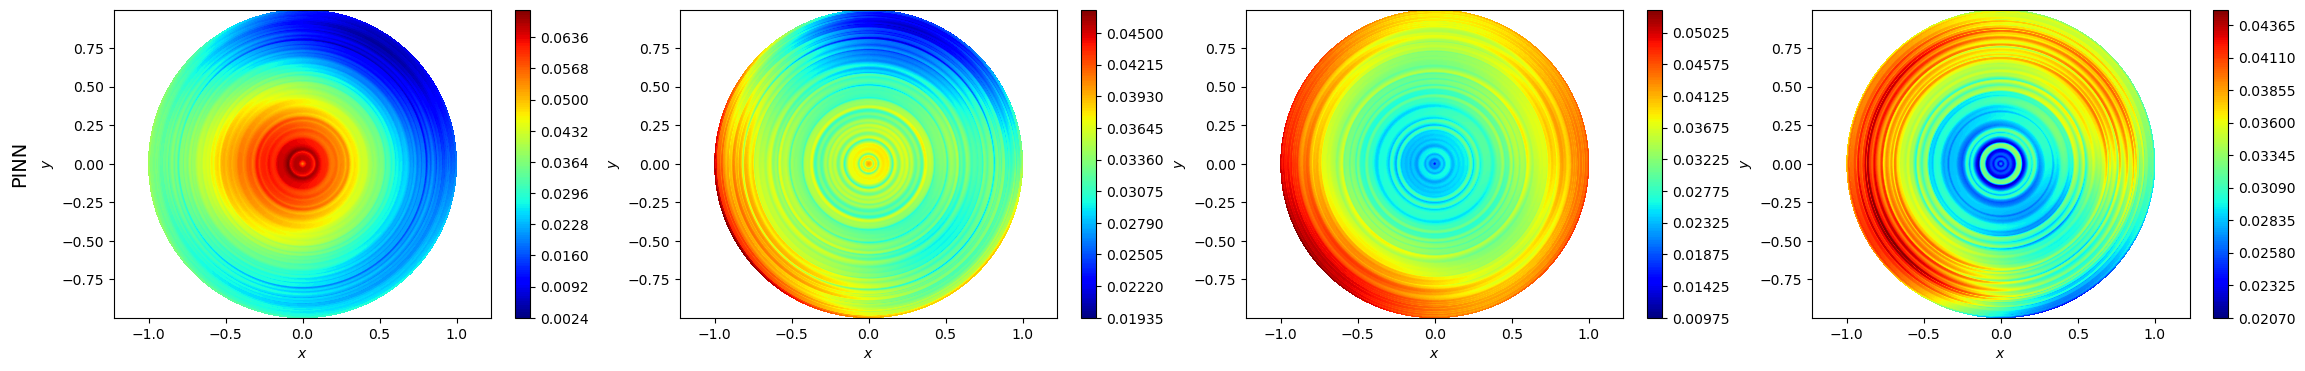

In [10]:
plt.figure(figsize=(28,4))
plt.subplot(1,4,1)
error_pinn = (y_pinn[0]-y_rel[0]).abs()
plt.axis('equal')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.contourf(x[:100,:,0],x[:100,:,1],(error_pinn[:100]+torch.flip(error_pinn[100:],(0,))).detach(),200,cmap='jet')
plt.colorbar()
plt.text(-0.25, 0.5, 'PINN',transform=plt.gca().transAxes,rotation=90,fontsize=14,va='center',ha='center')

plt.subplot(1,4,2)
error_pinn = (y_pinn[1]-y_rel[1]).abs()
plt.axis('equal')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.contourf(x[:100,:,0].cpu(),x[:100,:,1].cpu(),(error_pinn[:100]+torch.flip(error_pinn[100:],(0,))).detach(),200,cmap='jet')
plt.colorbar()

plt.subplot(1,4,3)
error_pinn = (y_pinn[2]-y_rel[2]).abs()
plt.axis('equal')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.contourf(x[:100,:,0].cpu(),x[:100,:,1].cpu(),(error_pinn[:100]+torch.flip(error_pinn[100:],(0,))).detach(),200,cmap='jet')
plt.colorbar()

plt.subplot(1,4,4)
error_pinn = (y_pinn[3]-y_rel[3]).abs()
plt.axis('equal')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.contourf(x[:100,:,0].cpu(),x[:100,:,1].cpu(),(error_pinn[:100]+torch.flip(error_pinn[100:],(0,))).detach(),200,cmap='jet')
plt.colorbar()
plt.savefig('./figures/rotation_error_pinn.pdf', bbox_inches='tight', dpi=2000, format='pdf')
plt.show()

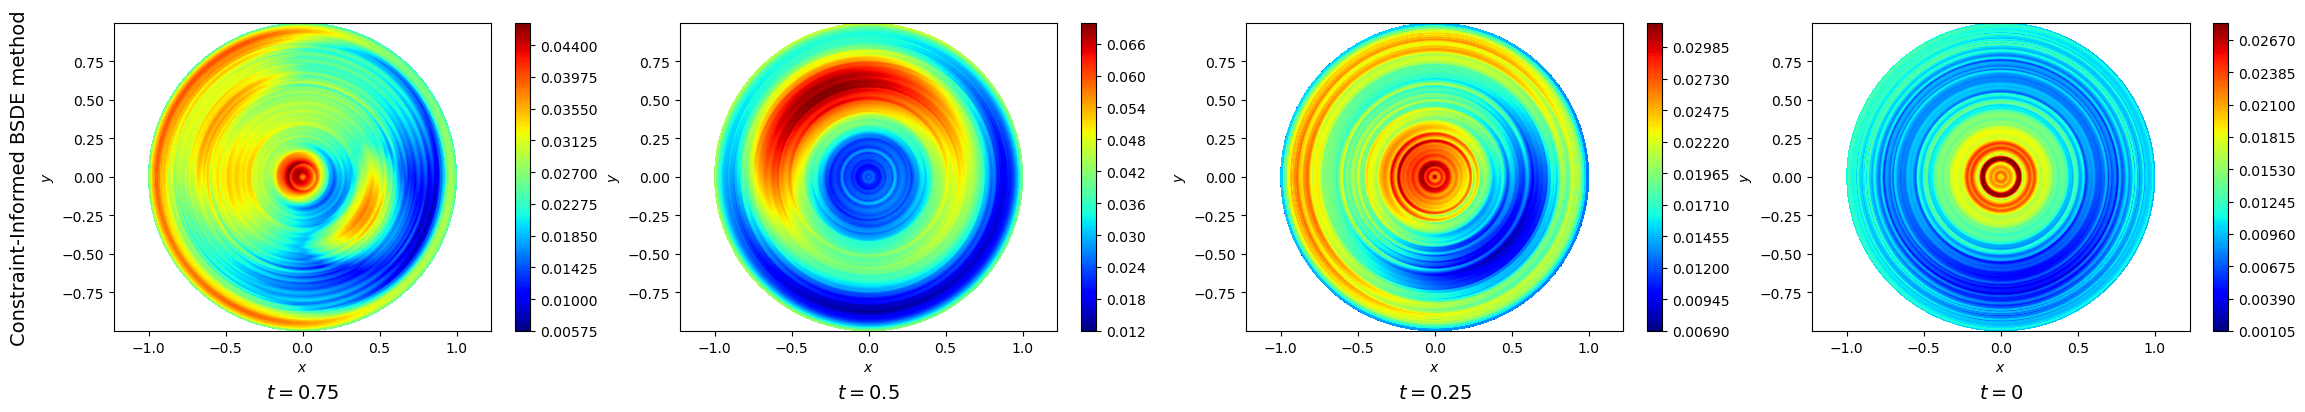

In [11]:
plt.figure(figsize=(28,4))
plt.subplot(1,4,1)
error_cibsde = (y_pre[0]-y_rel[0]).abs()
plt.axis('equal')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.text(0.5, -0.2, '$t=0.75$',transform=plt.gca().transAxes,fontsize=14,va='center',ha='center')
plt.contourf(x[:100,:,0],x[:100,:,1],(error_cibsde[:100]+torch.flip(error_cibsde[100:],(0,))).detach(),200,cmap='jet')
plt.colorbar()
plt.text(-0.25, 0.5, 'Constraint-Informed BSDE method',transform=plt.gca().transAxes,rotation=90,fontsize=14,va='center',ha='center')

plt.subplot(1,4,2)
error_cibsde = (y_pre[1]-y_rel[1]).abs()
plt.axis('equal')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.text(0.5, -0.2, '$t=0.5$',transform=plt.gca().transAxes,fontsize=14,va='center',ha='center')
plt.contourf(x[:100,:,0].cpu(),x[:100,:,1].cpu(),(error_cibsde[:100]+torch.flip(error_cibsde[100:],(0,))).detach(),200,cmap='jet')
plt.colorbar()

plt.subplot(1,4,3)
error_cibsde = (y_pre[2]-y_rel[2]).abs()
plt.axis('equal')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.text(0.5, -0.2, '$t=0.25$',transform=plt.gca().transAxes,fontsize=14,va='center',ha='center')
plt.contourf(x[:100,:,0].cpu(),x[:100,:,1].cpu(),(error_cibsde[:100]+torch.flip(error_cibsde[100:],(0,))).detach(),200,cmap='jet')
plt.colorbar()

plt.subplot(1,4,4)
error_cibsde = (y_pre[3]-y_rel[3]).abs()
plt.axis('equal')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.text(0.5, -0.2, '$t=0$',transform=plt.gca().transAxes,fontsize=14,va='center',ha='center')
plt.contourf(x[:100,:,0].cpu(),x[:100,:,1].cpu(),(error_cibsde[:100]+torch.flip(error_cibsde[100:],(0,))).detach(),200,cmap='jet')
plt.colorbar()
plt.savefig('./figures/rotation_error_cibsde.pdf', bbox_inches='tight', dpi=2000, format='pdf')
plt.show()

## Relative L2 errors

In [12]:
error_pinn = []
error_cibsde = []
for i in range(4):
    error_pinn.append(torch.sqrt(((y_pinn[i]-y_rel[i])**2).mean() / ((y_rel[i])**2).mean()))
    error_cibsde.append(torch.sqrt(((y_pre[i]-y_rel[i])**2).mean() / ((y_rel[i])**2).mean()))
print('Relative L2 errors \n', 'PINN: ', error_pinn, '\n', 'Ours: ', error_cibsde)

Relative L2 errors 
 PINN:  [tensor(0.0291), tensor(0.0228), tensor(0.0234), tensor(0.0214)] 
 Ours:  [tensor(0.0221), tensor(0.0262), tensor(0.0144), tensor(0.0084)]
